In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase.io import iread

input_file = 'eval_mace_small_vs_uma_omat.665.xyz'

In [2]:
rows = []
for atoms in iread(input_file):
    fe = np.abs(atoms.arrays['forces_true'] - atoms.arrays['forces_pred'])
    se = np.abs(atoms.info['stress_true'] - atoms.info['stress_pred'])
    rows.append({
        'traj_id': atoms.info['traj_id'],
        'frame_index': atoms.info['frame_index'],
        'n_atoms': len(atoms),
        'force_mae': fe.mean(),
        'force_rmse': np.sqrt((fe ** 2).mean()),
        'force_max_abs_error': fe.max(),
        'abs_energy_error_per_atom': abs(atoms.info['energy_true'] - atoms.info['energy_pred']) / len(atoms),
        'stress_mae': se.mean(),
        'stress_rmse': np.sqrt((se ** 2).mean()),
        'stress_max_abs_error': se.max(),
    })

df = pd.DataFrame(rows)

In [3]:
table = df.groupby('traj_id').agg(
    n_frames=('frame_index', 'count'),
    force_mae_eV_per_A=('force_mae', 'mean'),
    force_max_abs_error_eV_per_A=('force_max_abs_error', 'mean'),
    abs_energy_error_per_atom_eV=('abs_energy_error_per_atom', 'mean'),
    stress_mae_eV_per_A3=('stress_mae', 'mean'),
    stress_max_abs_error_eV_per_A3=('stress_max_abs_error', 'mean'),
).reset_index()
table

,traj_id,n_frames,force_mae_eV_per_A,force_max_abs_error_eV_per_A,abs_energy_error_per_atom_eV,stress_mae_eV_per_A3,stress_max_abs_error_eV_per_A3
0,0,10001,0.266875,1.510079,1.220190,0.011529,0.023226
1,1,10001,0.291176,1.950997,0.817623,0.008108,0.016577
2,2,10001,0.368901,2.122019,0.815695,0.009600,0.020008


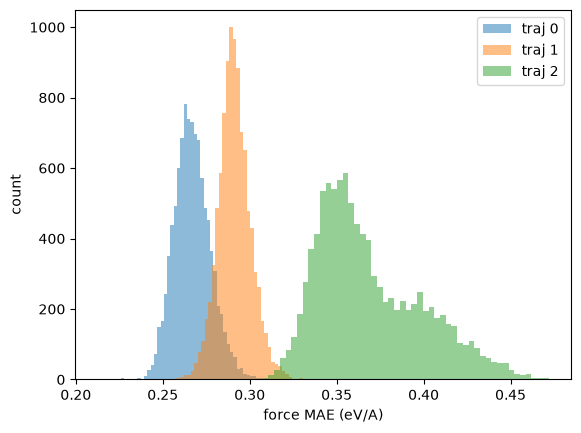

In [4]:
fig, ax = plt.subplots()
for traj_id, group in df.groupby('traj_id'):
    ax.hist(group['force_mae'], bins=50, alpha=0.5, label=f'traj {traj_id}')
ax.set_xlabel('force MAE (eV/A)')
ax.set_ylabel('count')
ax.legend()
plt.show()

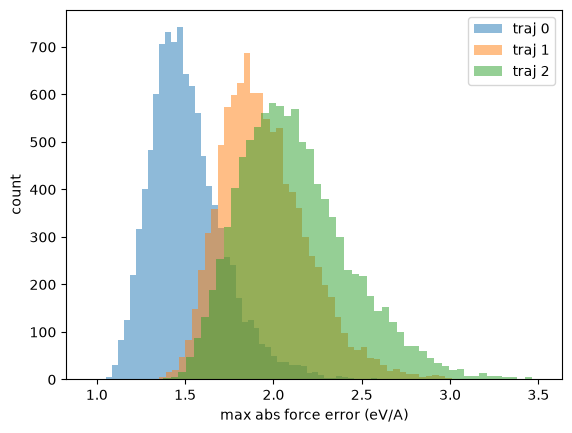

In [5]:
fig, ax = plt.subplots()
for traj_id, group in df.groupby('traj_id'):
    ax.hist(group['force_max_abs_error'], bins=50, alpha=0.5, label=f'traj {traj_id}')
ax.set_xlabel('max abs force error (eV/A)')
ax.set_ylabel('count')
ax.legend()
plt.show()

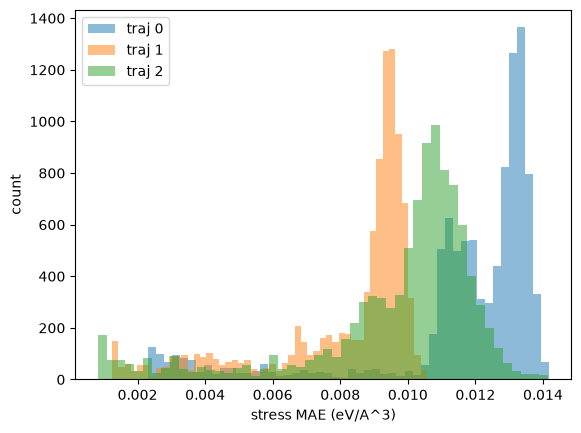

In [6]:
fig, ax = plt.subplots()
for traj_id, group in df.groupby('traj_id'):
    ax.hist(group['stress_mae'], bins=50, alpha=0.5, label=f'traj {traj_id}')
ax.set_xlabel('stress MAE (eV/A^3)')
ax.set_ylabel('count')
ax.legend()
plt.show()

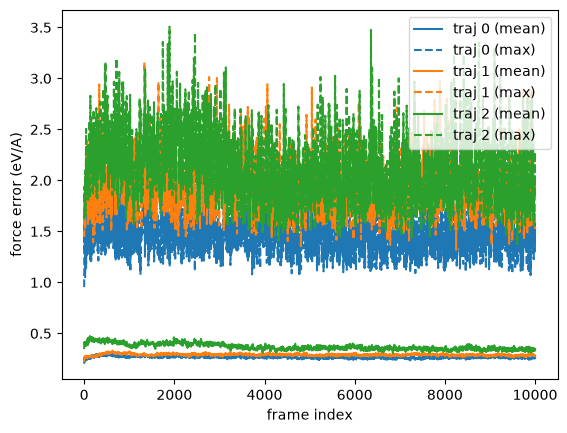

In [8]:
traj_ids = sorted(df['traj_id'].unique())
colors = plt.cm.tab10(range(len(traj_ids)))

fig, ax = plt.subplots()
for color, traj_id in zip(colors, traj_ids):
  group = df[df['traj_id'] == traj_id].sort_values('frame_index')
  ax.plot(group['frame_index'], group['force_mae'], color=color, linestyle='-', label=f'traj {traj_id} (mean)')
  ax.plot(group['frame_index'], group['force_max_abs_error'], color=color, linestyle='--', label=f'traj {traj_id} (max)')

ax.set_xlabel('frame index')
ax.set_ylabel('force error (eV/A)')
ax.legend()
plt.show()
